In [1]:
from pathlib import Path
import os
import pandas as pd
import polars as pl

import json

In [2]:
c_results_path = Path("Data/LLM_Results")
print(os.listdir(c_results_path))

['cluster_results_2016.jsonl', 'cluster_results_2017.jsonl', 'cluster_results_2018.jsonl', 'cluster_results_2019.jsonl', 'cluster_results_2020.jsonl', 'cluster_results_2021.jsonl', 'cluster_results_2022.jsonl', 'cluster_results_2023.jsonl', 'cluster_results_2024.jsonl']


In [3]:
c_results_files = os.listdir(c_results_path)
file_paths = []
for file in c_results_files:
    pfad = c_results_path / file
    file_paths.append(pfad)




In [5]:
import re

# Aggregieren aller Cluster-Ergebnisse in einen Datensatz
dfs_per_year = []

for pfad in file_paths:
    # Jahr aus Dateiname extrahieren (z.B. cluster_results_2016.jsonl)
    filename = pfad.name
    match = re.search(r'20\d\d', filename)
    if not match: continue
    jahr = match.group()
    
    # JSONL laden
    df_year = pl.read_ndjson(pfad)
    
    # Extrahieren (Syntax wie oben gewünscht)
    df_clean_year = df_year.with_columns([
        pl.col("content").str.extract(r"Subreddit Name: (r/\w+)").alias("subreddit"),
        (pl.col("model_output").str.extract(r'"is_political":\s*(true|false)') == "true").alias(jahr)
    ]).select(["subreddit", jahr]).unique(subset=["subreddit"])
    
    dfs_per_year.append(df_clean_year)

# Alle Jahre joinen (Outer Join stellt sicher, dass fehlende Jahre zu NA werden)
df_all_clusters = dfs_per_year[0]
for next_df in dfs_per_year[1:]:
    df_all_clusters = df_all_clusters.join(next_df, on="subreddit", how="full", coalesce=True)

# Sortieren nach Subreddit
df_all_clusters = df_all_clusters.sort("subreddit")

print("Aggregierte Cluster-Ergebnisse (Vorschau):")
print(df_all_clusters.head())

# Speichern als CSV
df_all_clusters.write_csv("all_cluster_results_political.csv")

Aggregierte Cluster-Ergebnisse (Vorschau):
shape: (5, 10)
┌────────────────┬──────┬──────┬───────┬───┬───────┬───────┬───────┬───────┐
│ subreddit      ┆ 2016 ┆ 2017 ┆ 2018  ┆ … ┆ 2021  ┆ 2022  ┆ 2023  ┆ 2024  │
│ ---            ┆ ---  ┆ ---  ┆ ---   ┆   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ str            ┆ bool ┆ bool ┆ bool  ┆   ┆ bool  ┆ bool  ┆ bool  ┆ bool  │
╞════════════════╪══════╪══════╪═══════╪═══╪═══════╪═══════╪═══════╪═══════╡
│ r/0ju1         ┆ null ┆ null ┆ null  ┆ … ┆ null  ┆ null  ┆ false ┆ null  │
│ r/0sanitymemes ┆ null ┆ null ┆ null  ┆ … ┆ false ┆ false ┆ false ┆ false │
│ r/0ue5         ┆ null ┆ null ┆ null  ┆ … ┆ null  ┆ null  ┆ false ┆ null  │
│ r/0xPolygon    ┆ null ┆ null ┆ null  ┆ … ┆ false ┆ false ┆ false ┆ false │
│ r/1000ccplus   ┆ null ┆ null ┆ false ┆ … ┆ false ┆ null  ┆ null  ┆ null  │
└────────────────┴──────┴──────┴───────┴───┴───────┴───────┴───────┴───────┘


,score_2016,Kategorie
politics,0.040198,Unbekannt
AskReddit,0.071990,Unbekannt
The_Donald,0.566429,Unbekannt
leagueoflegends,0.082231,Unbekannt
nfl,0.031358,Unbekannt


---
## Automatisierte Extraktion und Varianz-Analyse für alle Jahre
Der folgende Block iteriert über alle JSONL-Dateien, extrahiert die Subreddits (bereinigt das `r/`-Präfix) und berechnet die Varianz der politischen Scores für politische und unpolitische Gruppen.

Verarbeite Jahr: 2016
Verarbeite Jahr: 2017
Verarbeite Jahr: 2018
Warnung: score_2018 nicht in df_scores gefunden. Überspringe.
Verarbeite Jahr: 2019
Warnung: score_2019 nicht in df_scores gefunden. Überspringe.
Verarbeite Jahr: 2020
Warnung: score_2020 nicht in df_scores gefunden. Überspringe.
Verarbeite Jahr: 2021
Warnung: score_2021 nicht in df_scores gefunden. Überspringe.
Verarbeite Jahr: 2022
Warnung: score_2022 nicht in df_scores gefunden. Überspringe.
Verarbeite Jahr: 2023
Warnung: score_2023 nicht in df_scores gefunden. Überspringe.
Verarbeite Jahr: 2024
Warnung: score_2024 nicht in df_scores gefunden. Überspringe.

--- VARIANZ ÜBER DIE JAHRE ---
   Jahr  Var_Politisch  Var_Unpolitisch  Var_Unbekannt
0  2016       0.013185         0.004507       0.004621
1  2017       0.009036         0.005213       0.004571


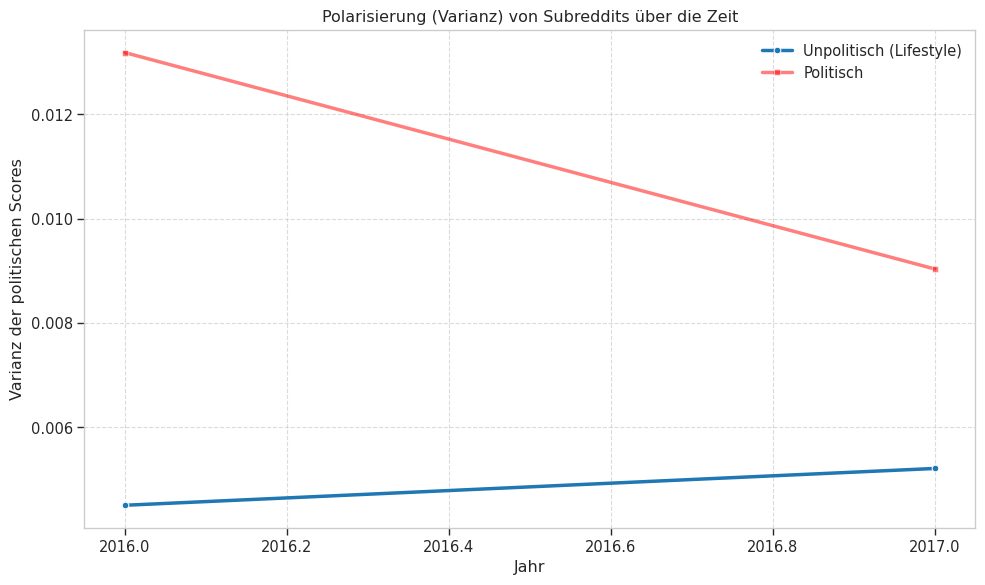

In [29]:
import re
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Plot-Einstellungen für wissenschaftliche Arbeiten
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# 1. Politische Scores laden
df_scores = pd.read_csv("politischer_wandel_2016_2024.csv", index_col=0)

variance_history = []

for pfad in file_paths:
    # Dateiname parsen, um das Jahr zu bekommen (z.B. cluster_results_2016.jsonl -> 2016)
    filename = pfad.name
    match = re.search(r'20\d\d', filename)
    if not match:
        continue
    jahr = match.group()
    
    print(f"Verarbeite Jahr: {jahr}")
    
    # JSONL mit Polars laden und parsen (wie in deiner Zelle oben)
    df_pl = pl.read_ndjson(pfad)
    df_clean = df_pl.with_columns([
        pl.col("content").str.extract(r"Subreddit Name: r/(\w+)").alias("subreddit"), # HIER direkt ohne r/ extrahieren
        (pl.col("model_output").str.extract(r'"is_political":\s*(true|false)') == "true").alias("is_political")
    ]).select(["subreddit", "is_political"]).drop_nulls()
    
    # In Pandas konvertieren und Sets bilden
    df_pd = df_clean.to_pandas()
    liste_politisch = set(df_pd[df_pd['is_political'] == True]['subreddit'])
    liste_unpolitisch = set(df_pd[df_pd['is_political'] == False]['subreddit'])
    
    # Wir brauchen die Scores für DIESES Jahr
    score_col = f"score_{jahr}"
    if score_col not in df_scores.columns:
        print(f"Warnung: {score_col} nicht in df_scores gefunden. Überspringe.")
        continue
        
    df_current_year = df_scores[[score_col]].dropna()
    
    # Kategorisieren
    def bestimme_kategorie(sub_name):
        if sub_name in liste_politisch:
            return "Politisch"
        elif sub_name in liste_unpolitisch:
            return "Unpolitisch"
        else:
            return "Unbekannt"

    df_current_year['Kategorie'] = df_current_year.index.map(bestimme_kategorie)
    
    # Varianz berechnen
    variances = df_current_year.groupby('Kategorie')[score_col].var()
    
    variance_history.append({
        'Jahr': int(jahr),
        'Var_Politisch': variances.get('Politisch', np.nan),
        'Var_Unpolitisch': variances.get('Unpolitisch', np.nan),
        'Var_Unbekannt': variances.get('Unbekannt', np.nan)
    })

# DataFrame aus der Historie erstellen und nach Jahr sortieren
df_variance_history = pd.DataFrame(variance_history).sort_values('Jahr')
print("\n--- VARIANZ ÜBER DIE JAHRE ---")
print(df_variance_history)

# --- PLOT ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_variance_history, x='Jahr', y='Var_Unpolitisch', marker='o', linewidth=2.5, label='Unpolitisch (Lifestyle)')
sns.lineplot(data=df_variance_history, x='Jahr', y='Var_Politisch', marker='s', linewidth=2.5, color='red', alpha=0.5, label='Politisch')

plt.title('Polarisierung (Varianz) von Subreddits über die Zeit')
plt.ylabel('Varianz der politischen Scores')
plt.xlabel('Jahr')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()